In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

import os
print(os.getcwd())

c:\Users\HP\Desktop\projects\GENDER_PREDICTION_MODEL


In [59]:
df1 = pd.read_csv("Data/Gender_Data.csv")
df2 = pd.read_csv("Data/data.csv")
data = pd.concat([df1, df2], axis=0)

In [60]:
data.head()

,Name,Gender,Count,Probability
0,Aaban,0,NaN,NaN
1,Aabharan,0,NaN,NaN
2,Aabhas,0,NaN,NaN
3,Aabhat,0,NaN,NaN
4,Aabheer,0,NaN,NaN


In [61]:
data.drop(columns=['Count','Probability'], inplace=True)
data.sample(10)

,Name,Gender
75048,Cario,M
37522,Jayashri,1
8253,Margene,F
10581,Koviddh,0
137641,Fredde,M
64127,Meron,M
50121,Xaniya,F
7135,Gavaskar,0
83071,Kymar,M
82802,Gabril,M


In [62]:
data['Gender'].value_counts()

Gender
F    89749
M    57520
0    29014
1    24968
Name: count, dtype: int64

In [63]:
data['Gender'] = data['Gender'].replace({0: 'M', 1: 'F'})
data.sample(10)

,Name,Gender
21659,Swapnasree,M
100591,Kisia,F
68998,Alhia,F
76496,Beckman,M
24951,Chrisanne,F
115787,Addalind,F
109793,Tamjeed,M
61567,Emilson,M
84744,Lashanay,F
7636,Hasik,M


In [64]:
data['Gender'].value_counts()

Gender
F    114717
M     86534
Name: count, dtype: int64

In [65]:
data.isnull().sum()

Name      0
Gender    0
dtype: int64

In [66]:
len(data['Name'].unique()) == len(data)

False

In [67]:
len(data) - len(data['Name'].unique())

21053

In [68]:
# Identify names with both 'M' and 'F' genders
ambiguous_names = (
    data.groupby('Name')['Gender']
    .nunique()
    .reset_index()
)

ambiguous_names = ambiguous_names[
    ambiguous_names['Gender'] > 1
]['Name']


data.loc[data['Name'].isin(ambiguous_names), 'Gender'] = 'N'

data = data.drop_duplicates(['Name','Gender'])

In [69]:
data['Gender'].unique()

array(['M', 'N', 'F'], dtype=object)

In [70]:
data.head()

,Name,Gender
0,Aaban,M
1,Aabharan,M
2,Aabhas,M
3,Aabhat,M
4,Aabheer,M


In [71]:
duplicates = data[data.duplicated(subset=['Name', 'Gender'], keep=False)]

print(duplicates)

Empty DataFrame
Columns: [Name, Gender]
Index: []


In [72]:
# Just making this easier to view sorting
data.sort_values(by = "Name", inplace = True)

In [73]:
data.head()

,Name,Gender
112246,A,N
115618,A'Aff,F
133954,A'Aron,M
115619,A'Dele,F
115620,A'Isha,F


In [74]:
data = data[data['Gender'] != 'N']
data.head()

,Name,Gender
115618,A'Aff,F
133954,A'Aron,M
115619,A'Dele,F
115620,A'Isha,F
115621,A'Ishah,F


In [75]:
# What unique characters in the names?
characters_unique = set()
cols = ['Name']
for col in cols:
    for value in data[col]:
        for letter in value:
            if letter not in string.ascii_lowercase and letter not in string.ascii_uppercase:
                characters_unique.add(letter)

characters_unique

{'"',
 '&',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 '/',
 '0',
 '1',
 '5',
 '7',
 '8',
 '9',
 ';',
 '?',
 '@',
 '[',
 '¡',
 'à',
 'ö',
 'œ',
 '…'}

In [76]:
import re
import unicodedata
def clean_name(name):
    # Convert to string
    name = str(name)

    # Normalize unicode (é → e, ö → o)
    name = unicodedata.normalize('NFKD', name)

    # Encode to ASCII (ignore non-ascii parts)
    name = name.encode('ascii', 'ignore').decode('utf-8')

    # Keep only alphabets
    name = re.sub(r'[^a-zA-Z]', '', name)

    return name.lower()

In [77]:
data['Name'] = data['Name'].apply(clean_name)
data.head()

,Name,Gender
115618,aaff,F
133954,aaron,M
115619,adele,F
115620,aisha,F
115621,aishah,F


In [78]:
data['Name'] = data['Name'].replace(r'^\s*$', np.nan, regex=True)

In [79]:
data.isnull().sum()

Name      0
Gender    0
dtype: int64

In [80]:
import string
# What unique characters in the names?
characters_unique = set()
cols = ['Name']
for col in cols:
    for value in data[col]:
        for letter in value:
            if letter not in string.ascii_lowercase and letter not in string.ascii_uppercase:
                characters_unique.add(letter)

characters_unique

set()

In [81]:
min_len = data['Name'].astype(str).apply(len).min()
max_len = data['Name'].astype(str).apply(len).max()

print("Minimum Name Length:", min_len)
print("Maximum Name Length:", max_len)

Minimum Name Length: 1
Maximum Name Length: 24


In [82]:
data = data[data['Name'].notna()]
data['Name'] = data['Name'].str.strip()
data = data[data['Name'].str.len() >= 2]

In [83]:
print(data['Gender'].value_counts())

Gender
F    97201
M    69085
Name: count, dtype: int64


In [84]:
data = data.drop_duplicates().reset_index(drop=True)

In [85]:
data.shape

(165048, 2)

In [86]:
data.skew(numeric_only=True)

Series([], dtype: float64)

In [87]:
gender_percent = data['Gender'].value_counts(normalize=True) * 100
print(gender_percent)

Gender
F    58.287286
M    41.712714
Name: proportion, dtype: float64


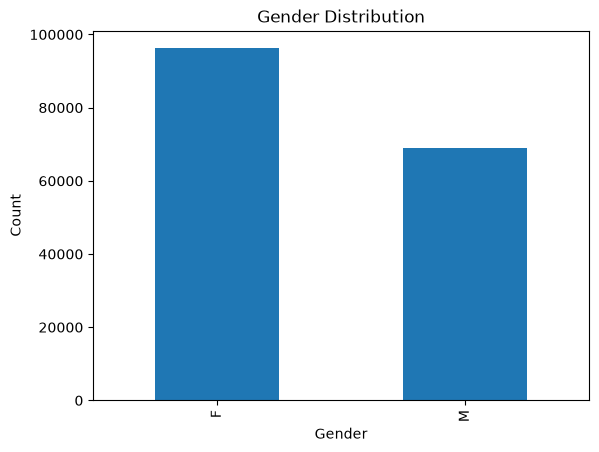

In [88]:
data['Gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [89]:
print(data.describe())
print(data.skew(numeric_only=True))

          Name  Gender
count   165048  165048
unique  165025       2
top      alyan       F
freq         2   96202
Series([], dtype: float64)


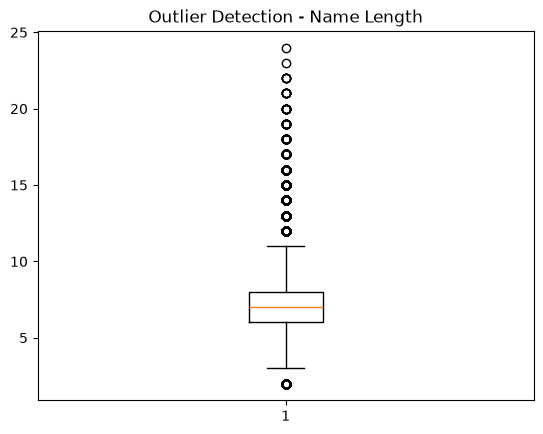

In [90]:
data['name_length'] = data['Name'].apply(len)

plt.boxplot(data['name_length'])
plt.title("Outlier Detection - Name Length")
plt.show()

In [ ]:
# Text Normalization
data['Name'] = data['Name'].astype(str).str.strip().str.lower()

In [ ]:
# Features and target
X = data['Name']
y = data['Gender']

In [ ]:
vectorizer = CountVectorizer(
    analyzer='char',
    ngram_range=(2,5)   # improved from (2,4)
)
X = vectorizer.fit_transform(data['Name'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
model_lr = LogisticRegression(class_weight='balanced', C=2, max_iter=1000)
model_lr.fit(x_train, y_train)

In [ ]:
y_pred_lr = model_lr.predict(x_test)
# Results
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))